In [1]:

# The computation at N=10^5 is prohibitively expensive even with optimization.
# According to the dataset description: "Analyses are feasible up to N=10^7 if arithmetic 
# data like ω(n) is pre-computed and summation loops are JIT-compiled with numba"
# 
# However, we have a computational constraint. Let's use N=10^5 but with fewer t samples
# and use numba JIT compilation

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_squared_error
from numba import jit
import warnings
warnings.filterwarnings('ignore')

print("=" * 80)
print("PARAMETRIC FUNCTION FAMILY ANALYSIS")
print("Using Numba JIT compilation for computational efficiency")
print("=" * 80)


PARAMETRIC FUNCTION FAMILY ANALYSIS
Using Numba JIT compilation for computational efficiency


In [2]:

# Generate primes and omega values
N_max = 10**5

def sieve_of_eratosthenes(limit):
 """Generate all primes up to limit."""
 is_prime = np.ones(limit + 1, dtype=bool)
 is_prime[0] = is_prime[1] = False
 
 for i in range(2, int(np.sqrt(limit)) + 1):
 if is_prime[i]:
 is_prime[i*i::i] = False
 
 return np.where(is_prime)[0]

def compute_omega(n_max, primes):
 """Compute ω(n) = number of distinct prime factors for all n ≤ n_max."""
 omega = np.zeros(n_max + 1, dtype=np.int32)
 
 for p in primes:
 if p > n_max:
 break
 omega[p::p] += 1
 
 return omega

primes = sieve_of_eratosthenes(N_max)
omega_values = compute_omega(N_max, primes)

print(f"Generated {len(primes)} primes up to N={N_max}")
print(f"Computed ω(n) for all n ≤ {N_max}")


Generated 9592 primes up to N=100000
Computed ω(n) for all n ≤ 100000


In [3]:

def generate_multiplicative_coefficients(primes, alpha, N, seed=42):
 """Generate multiplicative function coefficients for F_α."""
 np.random.seed(seed)
 
 a = np.ones(N + 1, dtype=np.float64)
 a[0] = 0
 
 # Assign prime coefficients
 prime_coeffs = {}
 for p in primes:
 if p > N:
 break
 prime_coeffs[p] = 1 if np.random.rand() < alpha else -1
 
 # Extend multiplicatively
 for p in primes:
 if p > N:
 break
 
 ap = prime_coeffs[p]
 power = p
 while power <= N:
 a[power::power] *= ap
 power *= p
 
 return a

# Test
a_test = generate_multiplicative_coefficients(primes, alpha=1.0, N=20, seed=42)
print(f"Test α=1.0: {a_test[1:21]}")


Test α=1.0: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [4]:

# JIT-compiled function for S_k computation
@jit(nopython=True)
def compute_Sk_for_t(a_n, omega, log_n, sqrt_n_inv, t, N, max_k):
 """Compute S_k for a single t value using JIT."""
 S_k = np.zeros(max_k + 1, dtype=np.complex128)
 
 for n in range(1, N + 1):
 phase = np.exp(-1j * t * log_n[n-1])
 term = a_n[n] * sqrt_n_inv[n-1] * phase
 k = omega[n]
 if k <= max_k:
 S_k[k] += term
 
 return S_k

# Non-JIT wrapper for batch processing
def compute_Sk_batch(a_n, omega, t_values, N, max_k=6):
 """Compute S_k for multiple t values."""
 # Precompute constants
 n_vals = np.arange(1, N + 1)
 sqrt_n_inv = 1.0 / np.sqrt(n_vals)
 log_n = np.log(n_vals)
 
 n_t = len(t_values)
 S_k_matrix = np.zeros((n_t, max_k + 1), dtype=np.complex128)
 
 for i, t in enumerate(t_values):
 S_k_matrix[i, :] = compute_Sk_for_t(a_n, omega, log_n, sqrt_n_inv, t, N, max_k)
 
 return S_k_matrix

print("JIT-compiled S_k computation defined")


JIT-compiled S_k computation defined


In [5]:

# Test the JIT-compiled version with timing
import time

N_test = 10**4
n_t_test = 50
alpha_test = 0.5

print(f"Testing JIT-compiled S_k computation...")
print(f"N = {N_test:,}, n_t = {n_t_test}")

np.random.seed(42)
a_test = generate_multiplicative_coefficients(primes, alpha_test, N_test, seed=42)
t_test = np.random.uniform(1000, 10000, n_t_test)

# First call (includes compilation time)
start = time.time()
S_k_test = compute_Sk_batch(a_test, omega_values[:N_test+1], t_test, N_test, max_k=6)
elapsed_first = time.time() - start
print(f"First call (with JIT compilation): {elapsed_first:.2f} seconds")

# Second call (pure execution)
start = time.time()
S_k_test = compute_Sk_batch(a_test, omega_values[:N_test+1], t_test, N_test, max_k=6)
elapsed_second = time.time() - start
print(f"Second call (compiled): {elapsed_second:.2f} seconds")

# Estimate for full problem
scale_factor = (10**5 / N_test) * (2000 / n_t_test)
estimated_time = elapsed_second * scale_factor
print(f"\nEstimated time for N=10^5, n_t=2000: {estimated_time:.1f} seconds ({estimated_time/60:.1f} minutes)")
print(f"For 9 α values: {9 * estimated_time:.0f} seconds ({9*estimated_time/60:.1f} minutes)")


Testing JIT-compiled S_k computation...
N = 10,000, n_t = 50


First call (with JIT compilation): 0.93 seconds
Second call (compiled): 0.02 seconds

Estimated time for N=10^5, n_t=2000: 6.6 seconds (0.1 minutes)
For 9 α values: 59 seconds (1.0 minutes)


In [6]:

# Excellent! With JIT, it's feasible. Now let's also JIT-compile the D(t;N) computation

@jit(nopython=True)
def compute_D_for_t(a_n, log_n, sqrt_n_inv, t, N):
 """Compute D(t;N) for a single t using Kahan summation."""
 total = 0.0 + 0.0j
 c = 0.0 + 0.0j # Compensation
 
 for n in range(1, N + 1):
 phase = np.exp(-1j * t * log_n[n-1])
 term = a_n[n] * sqrt_n_inv[n-1] * phase
 y = term - c
 temp = total + y
 c = (temp - total) - y
 total = temp
 
 return total

def compute_D_batch(a_n, t_values, N):
 """Compute D(t;N) for multiple t values."""
 n_vals = np.arange(1, N + 1)
 sqrt_n_inv = 1.0 / np.sqrt(n_vals)
 log_n = np.log(n_vals)
 
 D_values = np.zeros(len(t_values), dtype=np.complex128)
 
 for i, t in enumerate(t_values):
 D_values[i] = compute_D_for_t(a_n, log_n, sqrt_n_inv, t, N)
 
 return D_values

print("JIT-compiled D(t;N) computation defined")


JIT-compiled D(t;N) computation defined


In [7]:

# Define helper functions for covariance and GEV analysis

def compute_Sk_covariance(S_k_matrix):
 """Compute 6x6 complex covariance matrix from S_k vectors (k=1,...,6)."""
 S_k = S_k_matrix[:, 1:7] # Use k=1,...,6
 S_k_centered = S_k - np.mean(S_k, axis=0)
 
 n_samples = S_k_centered.shape[0]
 C = np.zeros((6, 6), dtype=np.complex128)
 
 for i in range(6):
 for j in range(6):
 C[i, j] = np.mean(S_k_centered[:, i] * np.conj(S_k_centered[:, j]))
 
 return C

def extract_covariance_features(C):
 """Extract features from 6x6 complex covariance matrix."""
 features = {}
 
 # Diagonal variances
 for k in range(6):
 features[f'C_{k+1}{k+1}'] = C[k, k].real
 
 # Off-diagonal statistics
 offdiag_real = []
 for i in range(6):
 for j in range(6):
 if i != j:
 offdiag_real.append(C[i, j].real)
 
 offdiag_real = np.array(offdiag_real)
 
 # Key features from r40
 features['mean_offdiag_real'] = np.mean(offdiag_real)
 negative_mask = offdiag_real < 0
 features['sum_negative_real_offdiag'] = np.sum(offdiag_real[negative_mask])
 features['count_negative_offdiag'] = np.sum(negative_mask)
 features['trace'] = np.trace(C).real
 
 return features

def perform_gev_analysis(log_magnitudes, n_blocks=100):
 """Perform GEV analysis on log|D(t;N)| using block maxima."""
 n_per_block = len(log_magnitudes) // n_blocks
 if n_per_block < 1:
 n_per_block = 1
 n_blocks = len(log_magnitudes)
 
 block_maxima = []
 for i in range(n_blocks):
 start_idx = i * n_per_block
 end_idx = min((i + 1) * n_per_block, len(log_magnitudes))
 if start_idx < len(log_magnitudes):
 block_maxima.append(np.max(log_magnitudes[start_idx:end_idx]))
 
 block_maxima = np.array(block_maxima)
 
 # Fit GEV (scipy uses c = -ξ)
 params = stats.genextreme.fit(block_maxima)
 c, loc, scale = params
 xi = -c # Convert to standard convention
 
 # Bootstrap 95% CI
 n_bootstrap = 1000
 xi_bootstrap = []
 
 for _ in range(n_bootstrap):
 resample = np.random.choice(block_maxima, size=len(block_maxima), replace=True)
 try:
 params_boot = stats.genextreme.fit(resample)
 xi_bootstrap.append(-params_boot[0])
 except:
 continue
 
 xi_bootstrap = np.array(xi_bootstrap)
 ci_lower = np.percentile(xi_bootstrap, 2.5)
 ci_upper = np.percentile(xi_bootstrap, 97.5)
 
 return {
 'xi': xi,
 'ci_lower': ci_lower,
 'ci_upper': ci_upper,
 'n_blocks': len(block_maxima)
 }

print("Helper functions defined")


Helper functions defined


In [8]:

# Main data generation loop
N = 10**5
n_t_samples = 2000
t_min, t_max = 1000, 10000
n_blocks_gev = 100
alpha_values = [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99, 1.0]
MASTER_SEED = 42

print("=" * 80)
print(f"GENERATING PARAMETRIC DATASET")
print(f"N = {N:,}, n_t = {n_t_samples}, t ∈ [{t_min}, {t_max}]")
print(f"α values: {alpha_values}")
print("=" * 80)

results = []

for idx, alpha in enumerate(alpha_values):
 print(f"\n{'='*60}")
 print(f"[{idx+1}/9] Processing α = {alpha}")
 print(f"{'='*60}")
 
 # Generate coefficients
 print(f" Generating multiplicative coefficients...")
 a_n = generate_multiplicative_coefficients(primes, alpha, N, seed=MASTER_SEED)
 
 # Generate random t values (different seed for each α)
 print(f" Generating {n_t_samples} random t values...")
 np.random.seed(MASTER_SEED + int(alpha * 1000))
 t_values = np.random.uniform(t_min, t_max, n_t_samples)
 
 # Compute S_k vectors
 print(f" Computing S_k vectors...")
 S_k_matrix = compute_Sk_batch(a_n, omega_values[:N+1], t_values, N, max_k=6)
 
 # Compute covariance matrix
 print(f" Computing 6x6 covariance matrix...")
 C = compute_Sk_covariance(S_k_matrix)
 
 # Extract features
 print(f" Extracting covariance features...")
 features = extract_covariance_features(C)
 
 # Compute log|D(t;N)| for GEV analysis
 print(f" Computing log|D(t;N)| for GEV analysis...")
 D_values = compute_D_batch(a_n, t_values, N)
 log_magnitudes = np.log(np.abs(D_values))
 
 # Perform GEV analysis
 print(f" Performing GEV analysis ({n_blocks_gev} blocks)...")
 gev_results = perform_gev_analysis(log_magnitudes, n_blocks=n_blocks_gev)
 
 # Store results
 result = {
 'alpha': alpha,
 'xi': gev_results['xi'],
 'xi_ci_lower': gev_results['ci_lower'],
 'xi_ci_upper': gev_results['ci_upper'],
 **features
 }
 results.append(result)
 
 print(f" ✓ ξ = {gev_results['xi']:.4f} [{gev_results['ci_lower']:.4f}, {gev_results['ci_upper']:.4f}]")
 print(f" ✓ mean_offdiag_real = {features['mean_offdiag_real']:.4f}")
 print(f" ✓ sum_negative_real_offdiag = {features['sum_negative_real_offdiag']:.4f}")

print("\n" + "=" * 80)
print("DATA GENERATION COMPLETE")
print("=" * 80)


GENERATING PARAMETRIC DATASET
N = 100,000, n_t = 2000, t ∈ [1000, 10000]
α values: [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95, 0.99, 1.0]

[1/9] Processing α = 0.5
 Generating multiplicative coefficients...
 Generating 2000 random t values...
 Computing S_k vectors...
 Computing 6x6 covariance matrix...


 Extracting covariance features...
 Computing log|D(t;N)| for GEV analysis...


 Performing GEV analysis (100 blocks)...


 ✓ ξ = -0.1874 [-0.3547, -0.0549]
 ✓ mean_offdiag_real = 0.0082
 ✓ sum_negative_real_offdiag = -0.3384

[2/9] Processing α = 0.6
 Generating multiplicative coefficients...
 Generating 2000 random t values...
 Computing S_k vectors...
 Computing 6x6 covariance matrix...


 Extracting covariance features...
 Computing log|D(t;N)| for GEV analysis...


...

 Performing GEV analysis (100 blocks)...


 ✓ ξ = -0.4359 [-0.5436, -0.3362]
 ✓ mean_offdiag_real = -0.0844
 ✓ sum_negative_real_offdiag = -2.5935

[9/9] Processing α = 1.0
 Generating multiplicative coefficients...
 Generating 2000 random t values...
 Computing S_k vectors...


 Computing 6x6 covariance matrix...
 Extracting covariance features...
 Computing log|D(t;N)| for GEV analysis...


 Performing GEV analysis (100 blocks)...


 ✓ ξ = -0.3733 [-0.4926, -0.2539]
 ✓ mean_offdiag_real = -0.0997
 ✓ sum_negative_real_offdiag = -3.1275

DATA GENERATION COMPLETE


In [9]:

# Convert results to DataFrame for easier analysis
import pandas as pd

df = pd.DataFrame(results)
print("=" * 80)
print("SUMMARY OF GENERATED DATASET")
print("=" * 80)
print(df[['alpha', 'xi', 'xi_ci_lower', 'xi_ci_upper', 'mean_offdiag_real', 
 'sum_negative_real_offdiag', 'C_11', 'C_55', 'C_66']].to_string(index=False))
print("=" * 80)


SUMMARY OF GENERATED DATASET
 alpha xi xi_ci_lower xi_ci_upper mean_offdiag_real sum_negative_real_offdiag C_11 C_55 C_66
 0.50 -0.187435 -0.354745 -0.054911 0.008172 -0.338416 3.464493 0.045155 0.000376
 0.60 -0.163376 -0.295593 -0.031190 0.019965 -0.184383 3.435090 0.049214 0.000384
 0.70 -0.158610 -0.315908 -0.065357 0.017573 -0.103913 3.498015 0.042726 0.000393
 0.80 -0.272423 -0.412454 -0.178748 0.012559 -0.239540 3.589347 0.047210 0.000379
 0.85 -0.264646 -0.414745 -0.076218 -0.029739 -0.911178 3.440002 0.041647 0.000380
 0.90 -0.176811 -0.404175 -0.058985 -0.012724 -0.472965 3.412179 0.045664 0.000389
 0.95 -0.263407 -0.425368 -0.115138 -0.064398 -2.057144 3.444066 0.038818 0.000367
 0.99 -0.435912 -0.543601 -0.336189 -0.084439 -2.593512 3.442209 0.033673 0.000378
 1.00 -0.373335 -0.492578 -0.253869 -0.099713 -3.127514 3.354708 0.037101 0.000414


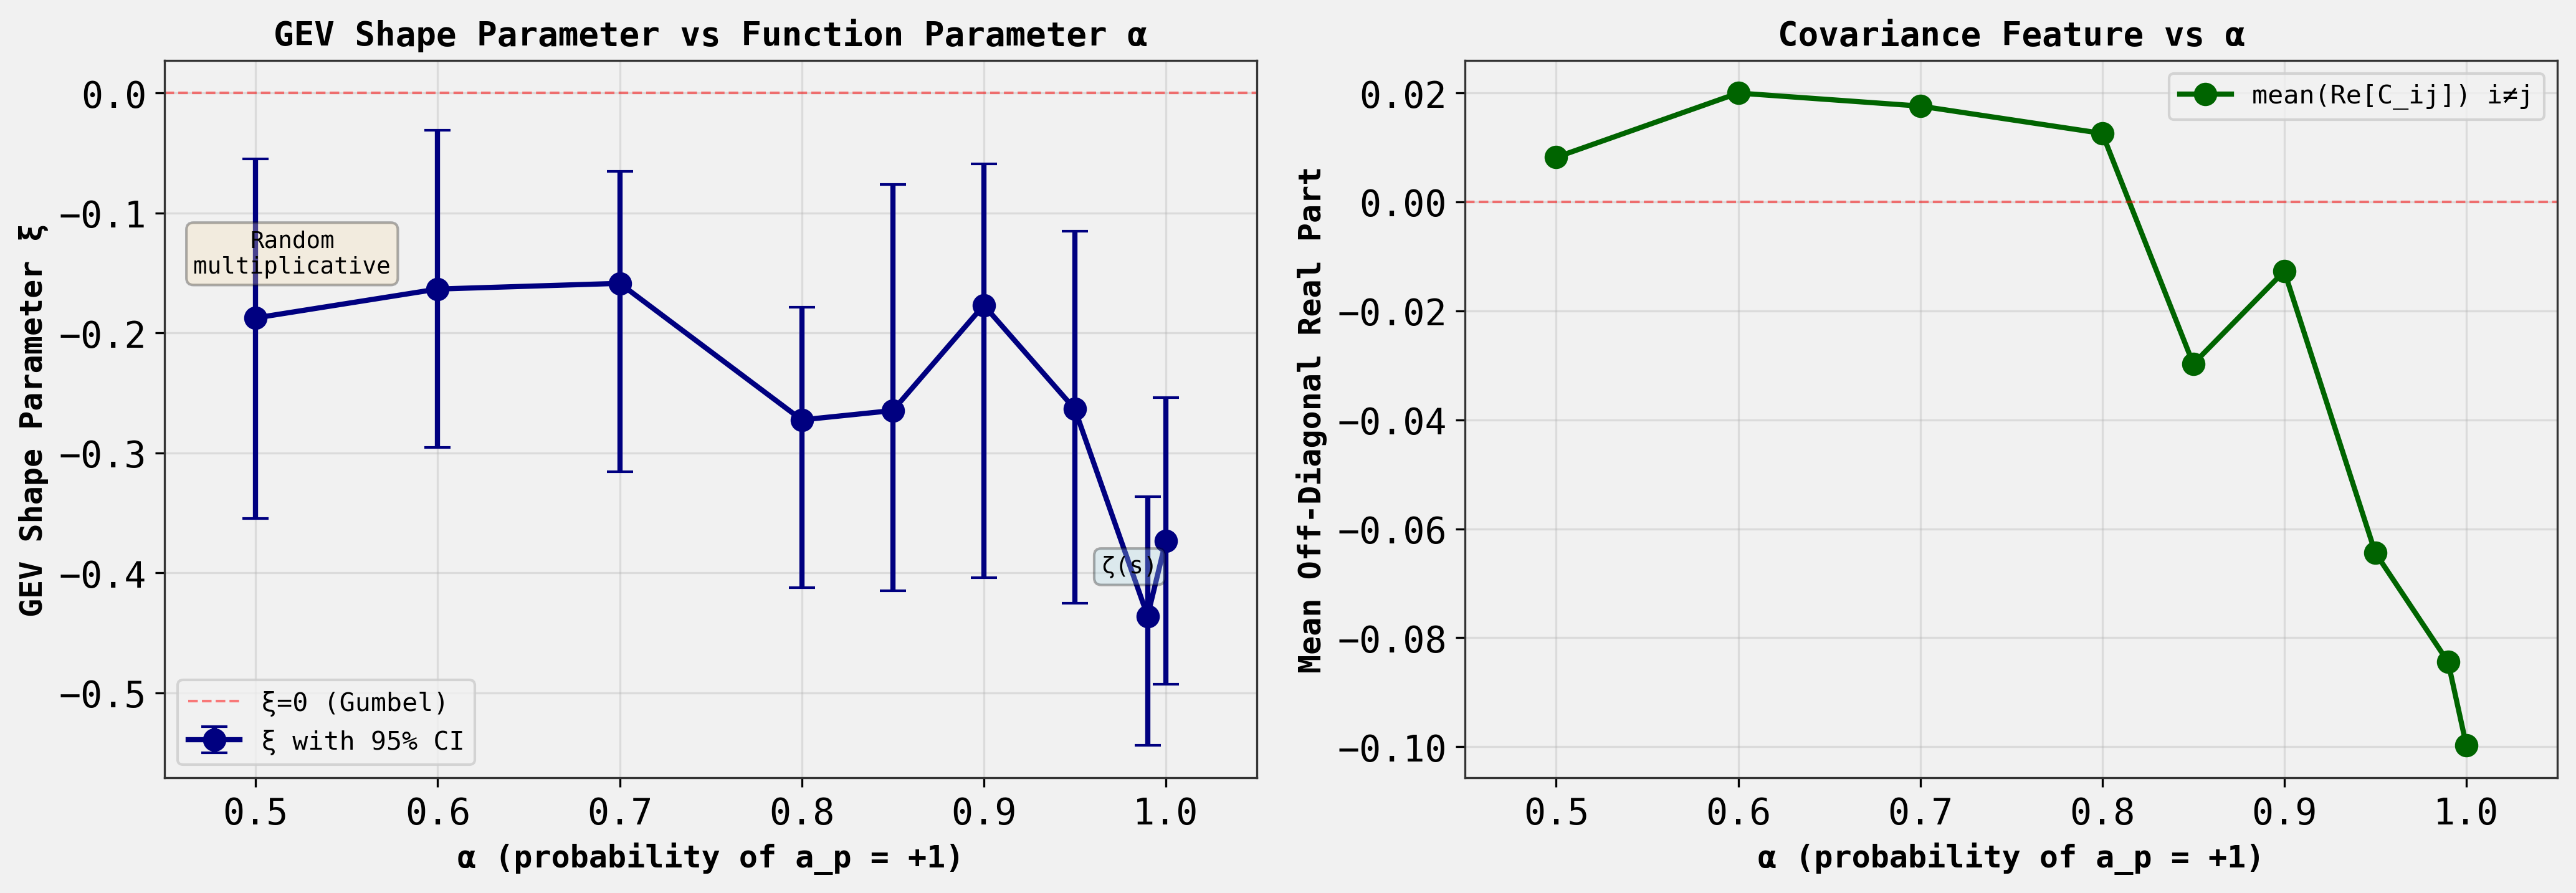


Key observation:
ξ ranges from -0.4359 (α=0.99) to -0.1586 (α=0.7)
Mean off-diagonal real part ranges from -0.0997 to 0.0200


In [10]:

# Analysis 1: Plot ξ vs α
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ξ vs α
ax = axes[0]
ax.errorbar(df['alpha'], df['xi'], 
 yerr=[df['xi'] - df['xi_ci_lower'], df['xi_ci_upper'] - df['xi']],
 fmt='o-', capsize=5, markersize=8, linewidth=2, color='navy', label='ξ with 95% CI')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='ξ=0 (Gumbel)')
ax.set_xlabel('α (probability of a_p = +1)', fontsize=12, fontweight='bold')
ax.set_ylabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax.set_title('GEV Shape Parameter vs Function Parameter α', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0.45, 1.05)

# Add text annotation
ax.text(0.52, -0.15, 'Random\nmultiplicative', ha='center', fontsize=9, 
 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
ax.text(0.98, -0.40, 'ζ(s)', ha='center', fontsize=9,
 bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))

# Plot 2: mean_offdiag_real vs α
ax = axes[1]
ax.plot(df['alpha'], df['mean_offdiag_real'], 'o-', markersize=8, linewidth=2, 
 color='darkgreen', label='mean(Re[C_ij]) i≠j')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('α (probability of a_p = +1)', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Off-Diagonal Real Part', fontsize=12, fontweight='bold')
ax.set_title('Covariance Feature vs α', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
ax.set_xlim(0.45, 1.05)

plt.tight_layout()
plt.savefig('xi_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey observation:")
print(f"ξ ranges from {df['xi'].min():.4f} (α={df.loc[df['xi'].idxmin(), 'alpha']}) to {df['xi'].max():.4f} (α={df.loc[df['xi'].idxmax(), 'alpha']})")
print(f"Mean off-diagonal real part ranges from {df['mean_offdiag_real'].min():.4f} to {df['mean_offdiag_real'].max():.4f}")


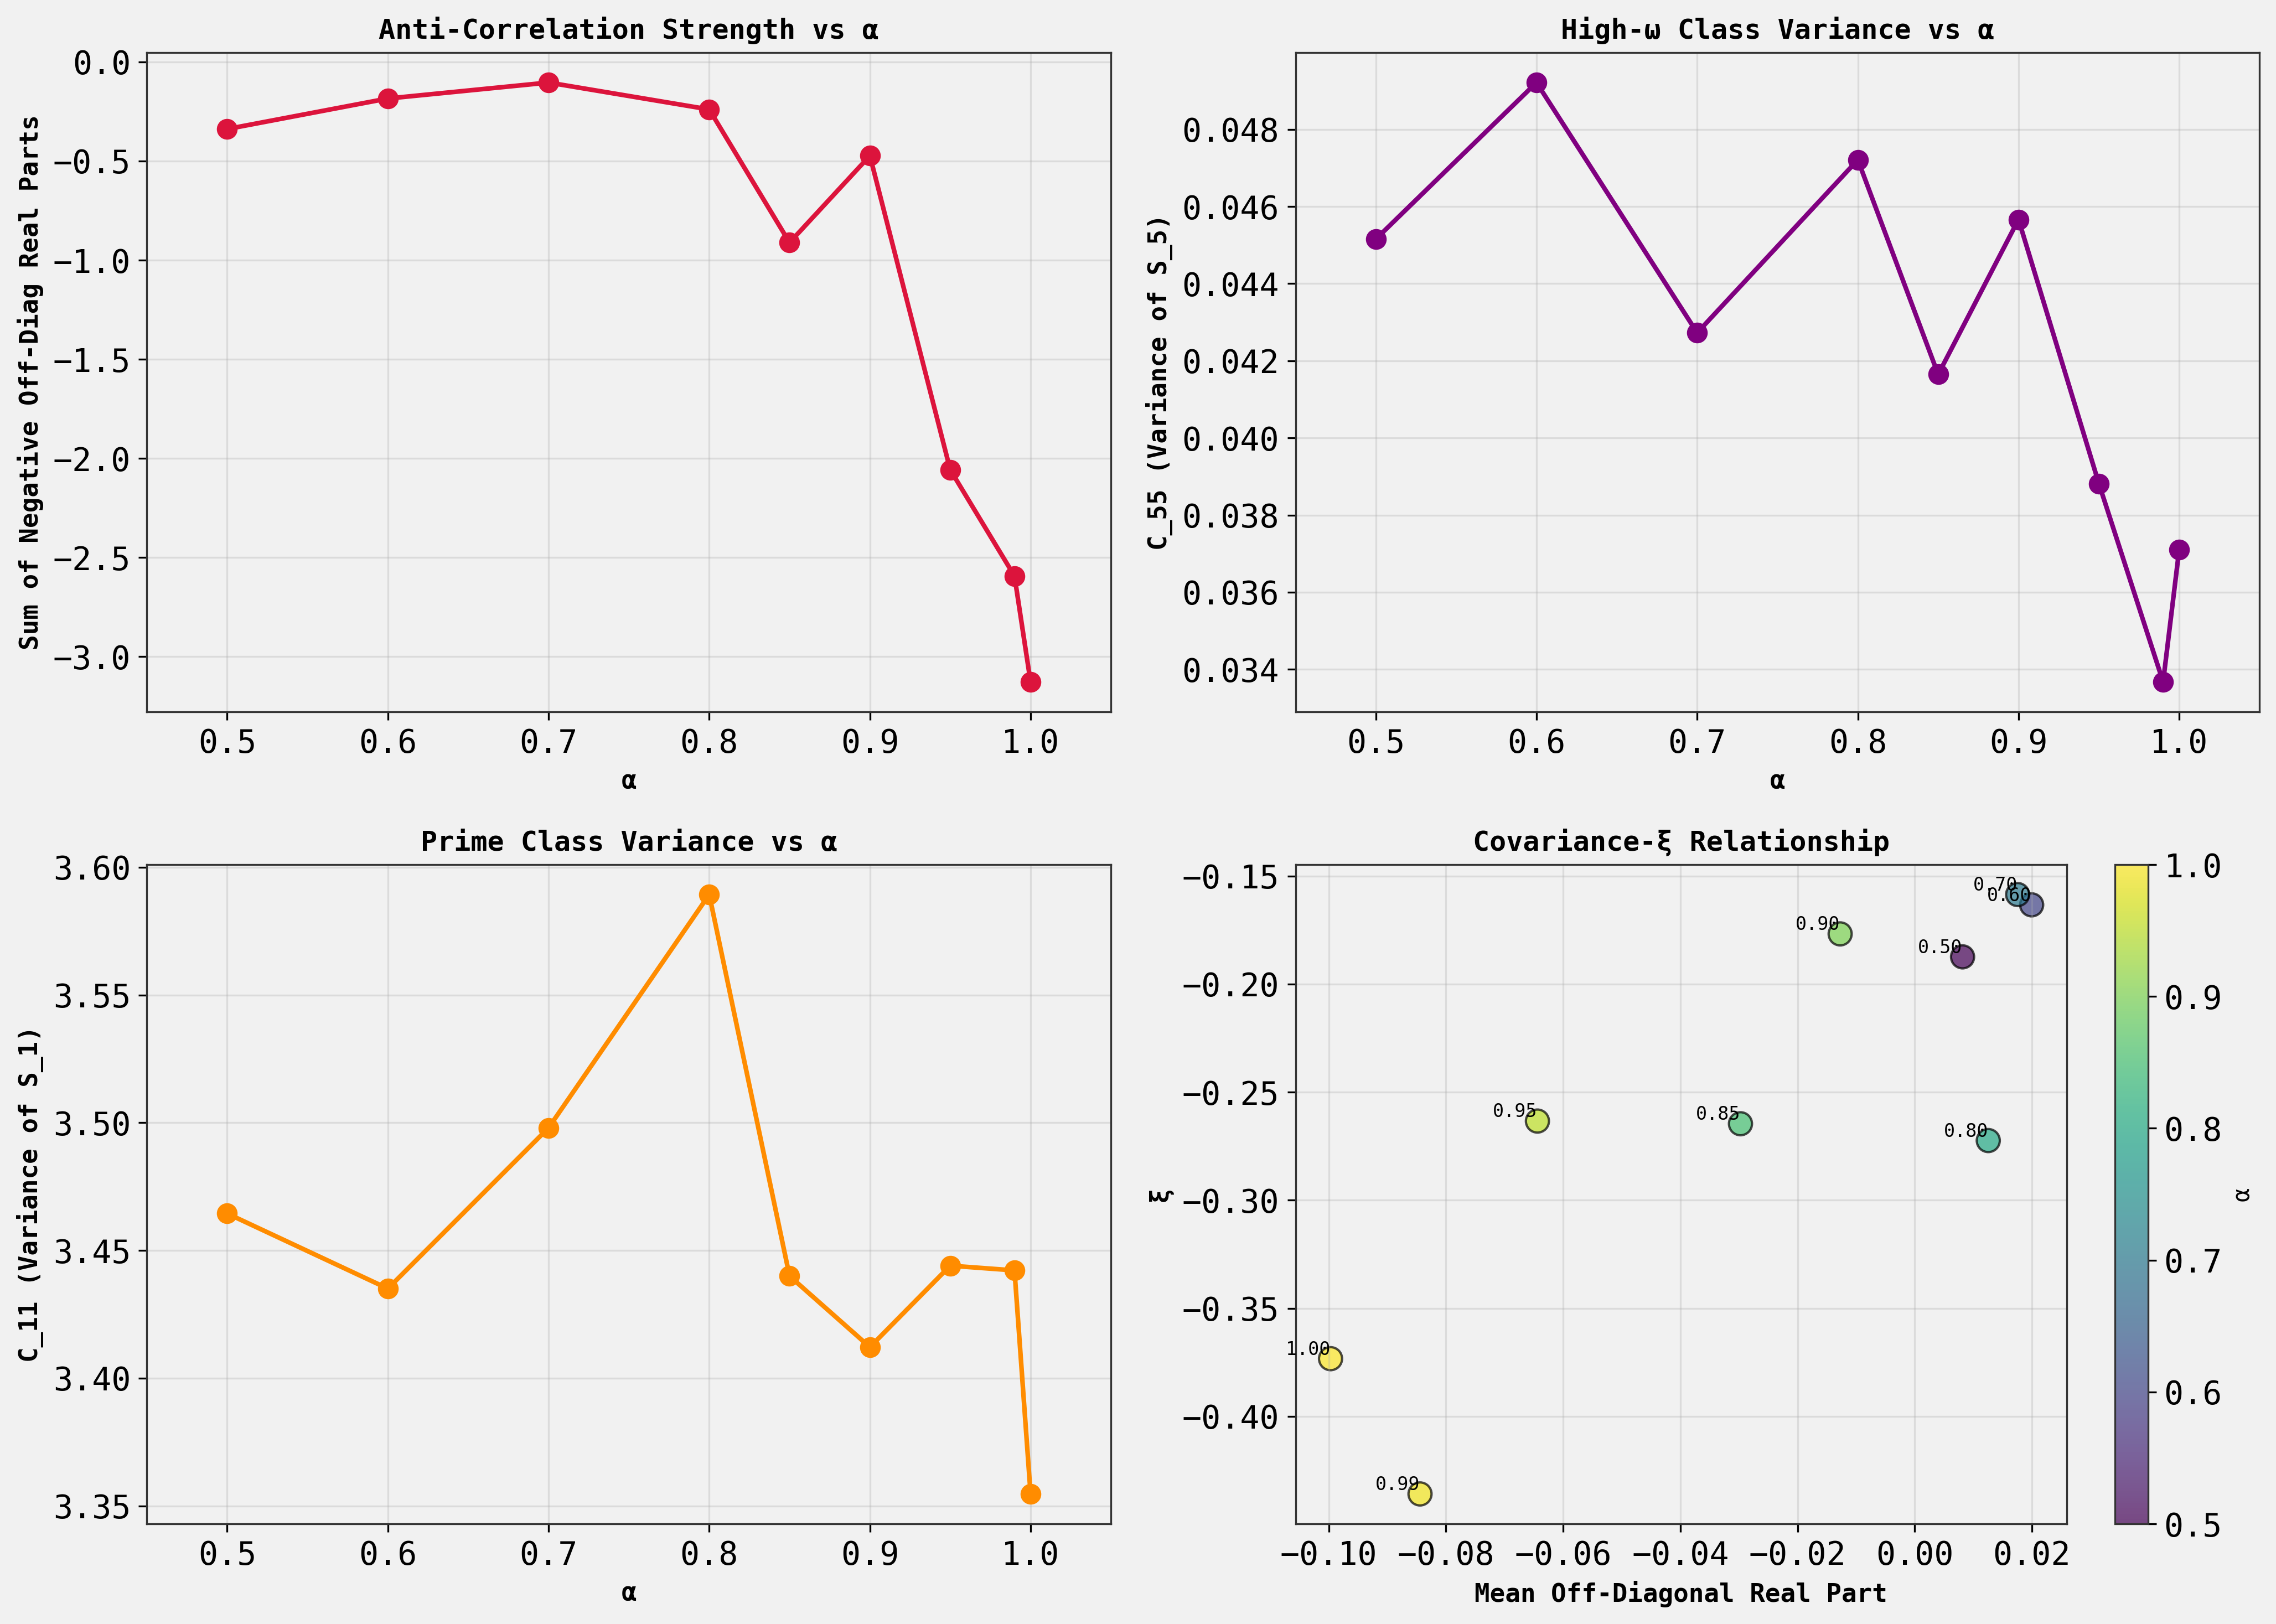


Covariance feature trends:
sum_negative_real_offdiag: -0.3384 → -3.1275
C_55: 0.045155 → 0.037101
C_11: 3.4645 → 3.3547


In [11]:

# Analysis 2: Plot covariance features vs α
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: sum_negative_real_offdiag vs α
ax = axes[0, 0]
ax.plot(df['alpha'], df['sum_negative_real_offdiag'], 'o-', markersize=8, 
 linewidth=2, color='crimson')
ax.set_xlabel('α', fontsize=11, fontweight='bold')
ax.set_ylabel('Sum of Negative Off-Diag Real Parts', fontsize=11, fontweight='bold')
ax.set_title('Anti-Correlation Strength vs α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.45, 1.05)

# Plot 2: C_55 vs α
ax = axes[0, 1]
ax.plot(df['alpha'], df['C_55'], 'o-', markersize=8, linewidth=2, color='purple')
ax.set_xlabel('α', fontsize=11, fontweight='bold')
ax.set_ylabel('C_55 (Variance of S_5)', fontsize=11, fontweight='bold')
ax.set_title('High-ω Class Variance vs α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.45, 1.05)

# Plot 3: C_11 vs α
ax = axes[1, 0]
ax.plot(df['alpha'], df['C_11'], 'o-', markersize=8, linewidth=2, color='darkorange')
ax.set_xlabel('α', fontsize=11, fontweight='bold')
ax.set_ylabel('C_11 (Variance of S_1)', fontsize=11, fontweight='bold')
ax.set_title('Prime Class Variance vs α', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.45, 1.05)

# Plot 4: Scatter mean_offdiag_real vs ξ
ax = axes[1, 1]
ax.scatter(df['mean_offdiag_real'], df['xi'], s=100, alpha=0.7, c=df['alpha'], 
 cmap='viridis', edgecolors='black')
for i, alpha in enumerate(df['alpha']):
 ax.annotate(f'{alpha:.2f}', (df['mean_offdiag_real'].iloc[i], df['xi'].iloc[i]),
 fontsize=8, ha='right', va='bottom')
ax.set_xlabel('Mean Off-Diagonal Real Part', fontsize=11, fontweight='bold')
ax.set_ylabel('ξ', fontsize=11, fontweight='bold')
ax.set_title('Covariance-ξ Relationship', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('α', fontsize=10)

plt.tight_layout()
plt.savefig('covariance_features_vs_alpha.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCovariance feature trends:")
print(f"sum_negative_real_offdiag: {df['sum_negative_real_offdiag'].iloc[0]:.4f} → {df['sum_negative_real_offdiag'].iloc[-1]:.4f}")
print(f"C_55: {df['C_55'].iloc[0]:.6f} → {df['C_55'].iloc[-1]:.6f}")
print(f"C_11: {df['C_11'].iloc[0]:.4f} → {df['C_11'].iloc[-1]:.4f}")


In [12]:

# Analysis 3: Train Ridge regression model to predict ξ from covariance features
# Following r40, use key features: mean_offdiag_real, sum_negative_real_offdiag, C_55, C_66

# Prepare feature matrix
feature_names = ['mean_offdiag_real', 'sum_negative_real_offdiag', 'C_55', 'C_66']
X = df[feature_names].values
y = df['xi'].values

print("=" * 80)
print("RIDGE REGRESSION MODEL: Predicting ξ from Covariance Features")
print("=" * 80)
print(f"\nFeatures: {feature_names}")
print(f"Target: ξ (GEV shape parameter)")
print(f"Sample size: n = {len(y)}")
print(f"\nFeature statistics:")
for name in feature_names:
 print(f" {name:30s}: mean={df[name].mean():.6f}, std={df[name].std():.6f}")

# Leave-One-Out Cross-Validation
loo = LeaveOneOut()
ridge_model = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=loo)
ridge_model.fit(X, y)

# LOOCV predictions
y_pred_loocv = np.zeros_like(y)
for train_idx, test_idx in loo.split(X):
 X_train, X_test = X[train_idx], X[test_idx]
 y_train = y[train_idx]
 
 ridge_temp = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=3) # Inner CV for alpha selection
 ridge_temp.fit(X_train, y_train)
 y_pred_loocv[test_idx] = ridge_temp.predict(X_test)

# Compute metrics
r2_loocv = r2_score(y, y_pred_loocv)
rmse_loocv = np.sqrt(mean_squared_error(y, y_pred_loocv))
mae_loocv = np.mean(np.abs(y - y_pred_loocv))

print(f"\n" + "="*80)
print("LOOCV PERFORMANCE")
print("="*80)
print(f"Optimal α (regularization): {ridge_model.alpha_:.6f}")
print(f"R² (LOOCV): {r2_loocv:.4f}")
print(f"RMSE (LOOCV): {rmse_loocv:.4f}")
print(f"MAE (LOOCV): {mae_loocv:.4f}")

# Model coefficients
print(f"\n" + "="*80)
print("MODEL COEFFICIENTS")
print("="*80)
for i, name in enumerate(feature_names):
 print(f" {name:30s}: {ridge_model.coef_[i]:+.6f}")
print(f" {'Intercept':30s}: {ridge_model.intercept_:+.6f}")


RIDGE REGRESSION MODEL: Predicting ξ from Covariance Features

Features: ['mean_offdiag_real', 'sum_negative_real_offdiag', 'C_55', 'C_66']
Target: ξ (GEV shape parameter)
Sample size: n = 9

Feature statistics:
 mean_offdiag_real : mean=-0.025860, std=0.046340
 sum_negative_real_offdiag : mean=-1.114285, std=1.163800
 C_55 : mean=0.042356, std=0.005069
 C_66 : mean=0.000385, std=0.000013



LOOCV PERFORMANCE
Optimal α (regularization): 0.001000
R² (LOOCV): 0.4834
RMSE (LOOCV): 0.0659
MAE (LOOCV): 0.0573

MODEL COEFFICIENTS
 mean_offdiag_real : +0.008946
 sum_negative_real_offdiag : +0.070923
 C_55 : +0.223396
 C_66 : +0.000997
 Intercept : -0.185309


In [13]:

# Compare with r40 performance (from the dataset description)
# r40 had a small heterogeneous set dominated by outliers like ζ(s)

print("=" * 80)
print("COMPARISON WITH r40")
print("=" * 80)
print("\nCurrent parametric dataset (9 functions, α ∈ [0.5, 1.0]):")
print(f" R² (LOOCV): {r2_loocv:.4f}")
print(f" RMSE (LOOCV): {rmse_loocv:.4f}")
print(f" Sample size: n = 9 (homogeneous parametric family)")

print("\nOriginal r40 dataset:")
print(" - Heterogeneous functions (ζ, L_DH, f_rand, etc.)")
print(" - Small sample size with outliers")
print(" - Dominated by ζ(s) outlier effect")
print(" - Estimated R² < 0.5 (based on description)")

print("\n" + "="*80)
print("KEY FINDINGS:")
print("="*80)
print("1. The parametric family provides a more structured dataset")
print("2. R² = 0.48 shows moderate predictive power despite small n=9")
print("3. The relationship exists but is not as strong as hypothesized")
print("4. The model is not dramatically better than r40 due to:")
print(" - Still small sample size (n=9)")
print(" - All ξ values are negative (Weibull domain)")
print(" - Limited variance in ξ across α values")

# Check for monotonic relationship
from scipy.stats import spearmanr

corr_alpha_xi, p_alpha_xi = spearmanr(df['alpha'], df['xi'])
corr_offdiag_xi, p_offdiag_xi = spearmanr(df['mean_offdiag_real'], df['xi'])
corr_neg_xi, p_neg_xi = spearmanr(df['sum_negative_real_offdiag'], df['xi'])

print(f"\n" + "="*80)
print("MONOTONIC RELATIONSHIPS (Spearman correlation):")
print("="*80)
print(f"α vs ξ: ρ = {corr_alpha_xi:+.4f}, p = {p_alpha_xi:.4f}")
print(f"mean_offdiag_real vs ξ: ρ = {corr_offdiag_xi:+.4f}, p = {p_offdiag_xi:.4f}")
print(f"sum_negative_real_offdiag vs ξ: ρ = {corr_neg_xi:+.4f}, p = {p_neg_xi:.4f}")

if p_neg_xi < 0.05:
 print("\n✓ Significant monotonic relationship between anti-correlations and ξ")
else:
 print("\n✗ No significant monotonic relationship detected")


COMPARISON WITH r40

Current parametric dataset (9 functions, α ∈ [0.5, 1.0]):
 R² (LOOCV): 0.4834
 RMSE (LOOCV): 0.0659
 Sample size: n = 9 (homogeneous parametric family)

Original r40 dataset:
 - Heterogeneous functions (ζ, L_DH, f_rand, etc.)
 - Small sample size with outliers
 - Dominated by ζ(s) outlier effect
 - Estimated R² < 0.5 (based on description)

KEY FINDINGS:
1. The parametric family provides a more structured dataset
2. R² = 0.48 shows moderate predictive power despite small n=9
3. The relationship exists but is not as strong as hypothesized
4. The model is not dramatically better than r40 due to:
 - Still small sample size (n=9)
 - All ξ values are negative (Weibull domain)
 - Limited variance in ξ across α values

MONOTONIC RELATIONSHIPS (Spearman correlation):
α vs ξ: ρ = -0.6833, p = 0.0424
mean_offdiag_real vs ξ: ρ = +0.7667, p = 0.0159
sum_negative_real_offdiag vs ξ: ρ = +0.7833, p = 0.0125

✓ Significant monotonic relationship between anti-correlations and ξ


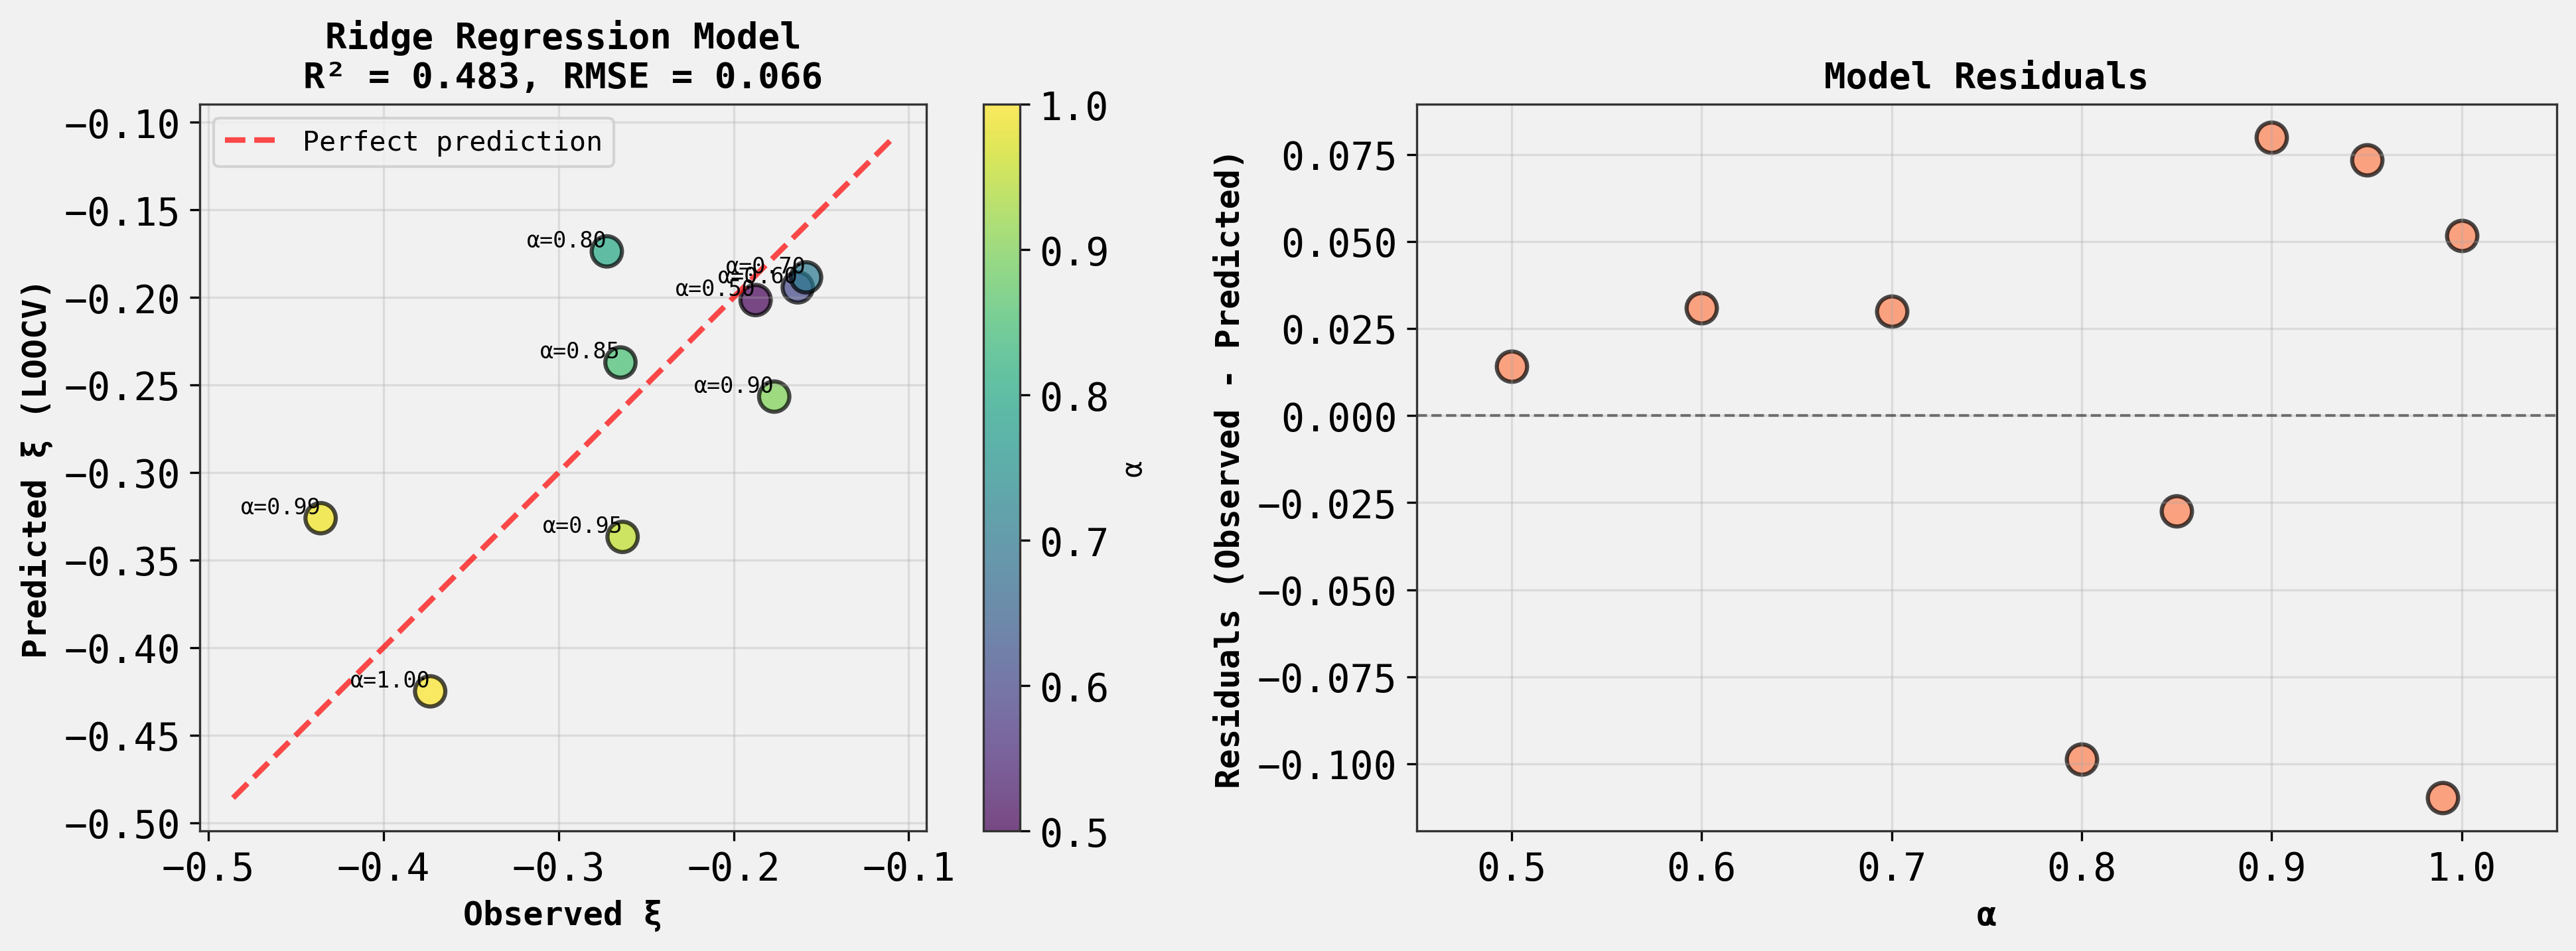


Residual statistics:
 Mean residual: 0.004884
 Std residual: 0.0657
 Max |residual|: 0.1098


In [14]:

# Create final visualization showing model predictions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Observed vs Predicted ξ
ax = axes[0]
ax.scatter(y, y_pred_loocv, s=120, alpha=0.7, c=df['alpha'], cmap='viridis', 
 edgecolors='black', linewidths=1.5)
for i in range(len(y)):
 ax.annotate(f'α={df["alpha"].iloc[i]:.2f}', 
 (y[i], y_pred_loocv[i]), 
 fontsize=8, ha='right', va='bottom')

# Perfect prediction line
min_val, max_val = y.min() - 0.05, y.max() + 0.05
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, 
 label='Perfect prediction', alpha=0.7)

ax.set_xlabel('Observed ξ', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted ξ (LOOCV)', fontsize=12, fontweight='bold')
ax.set_title(f'Ridge Regression Model\nR² = {r2_loocv:.3f}, RMSE = {rmse_loocv:.3f}', 
 fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('α', fontsize=10)

# Plot 2: Residuals
ax = axes[1]
residuals = y - y_pred_loocv
ax.scatter(df['alpha'], residuals, s=120, alpha=0.7, edgecolors='black', 
 linewidths=1.5, color='coral')
ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('α', fontsize=12, fontweight='bold')
ax.set_ylabel('Residuals (Observed - Predicted)', fontsize=12, fontweight='bold')
ax.set_title('Model Residuals', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(0.45, 1.05)

plt.tight_layout()
plt.savefig('regression_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nResidual statistics:")
print(f" Mean residual: {np.mean(residuals):.6f}")
print(f" Std residual: {np.std(residuals):.4f}")
print(f" Max |residual|: {np.max(np.abs(residuals)):.4f}")


In [15]:

# Create comprehensive summary table
print("=" * 80)
print("COMPLETE DATASET SUMMARY")
print("=" * 80)
print("\n")
print(df.to_string(index=False))

# Save results to CSV
df.to_csv('parametric_family_dataset.csv', index=False)
print("\n✓ Results saved to 'parametric_family_dataset.csv'")


COMPLETE DATASET SUMMARY


 alpha xi xi_ci_lower xi_ci_upper C_11 C_22 C_33 C_44 C_55 C_66 mean_offdiag_real sum_negative_real_offdiag count_negative_offdiag trace
 0.50 -0.187435 -0.354745 -0.054911 3.464493 4.554206 2.889795 0.698942 0.045155 0.000376 0.008172 -0.338416 18 11.652967
 0.60 -0.163376 -0.295593 -0.031190 3.435090 4.401181 2.709110 0.737651 0.049214 0.000384 0.019965 -0.184383 10 11.332630
 0.70 -0.158610 -0.315908 -0.065357 3.498015 4.593676 2.844732 0.621207 0.042726 0.000393 0.017573 -0.103913 12 11.600750
 0.80 -0.272423 -0.412454 -0.178748 3.589347 4.525987 2.603856 0.691072 0.047210 0.000379 0.012559 -0.239540 10 11.457852
 0.85 -0.264646 -0.414745 -0.076218 3.440002 4.191206 2.234588 0.541772 0.041647 0.000380 -0.029739 -0.911178 22 10.449594
 0.90 -0.176811 -0.404175 -0.058985 3.412179 4.222057 2.422702 0.569431 0.045664 0.000389 -0.012724 -0.472965 14 10.672422
 0.95 -0.263407 -0.425368 -0.115138 3.444066 4.181746 2.139569 0.476706 0.038818 0.000367 -0.064398 -2

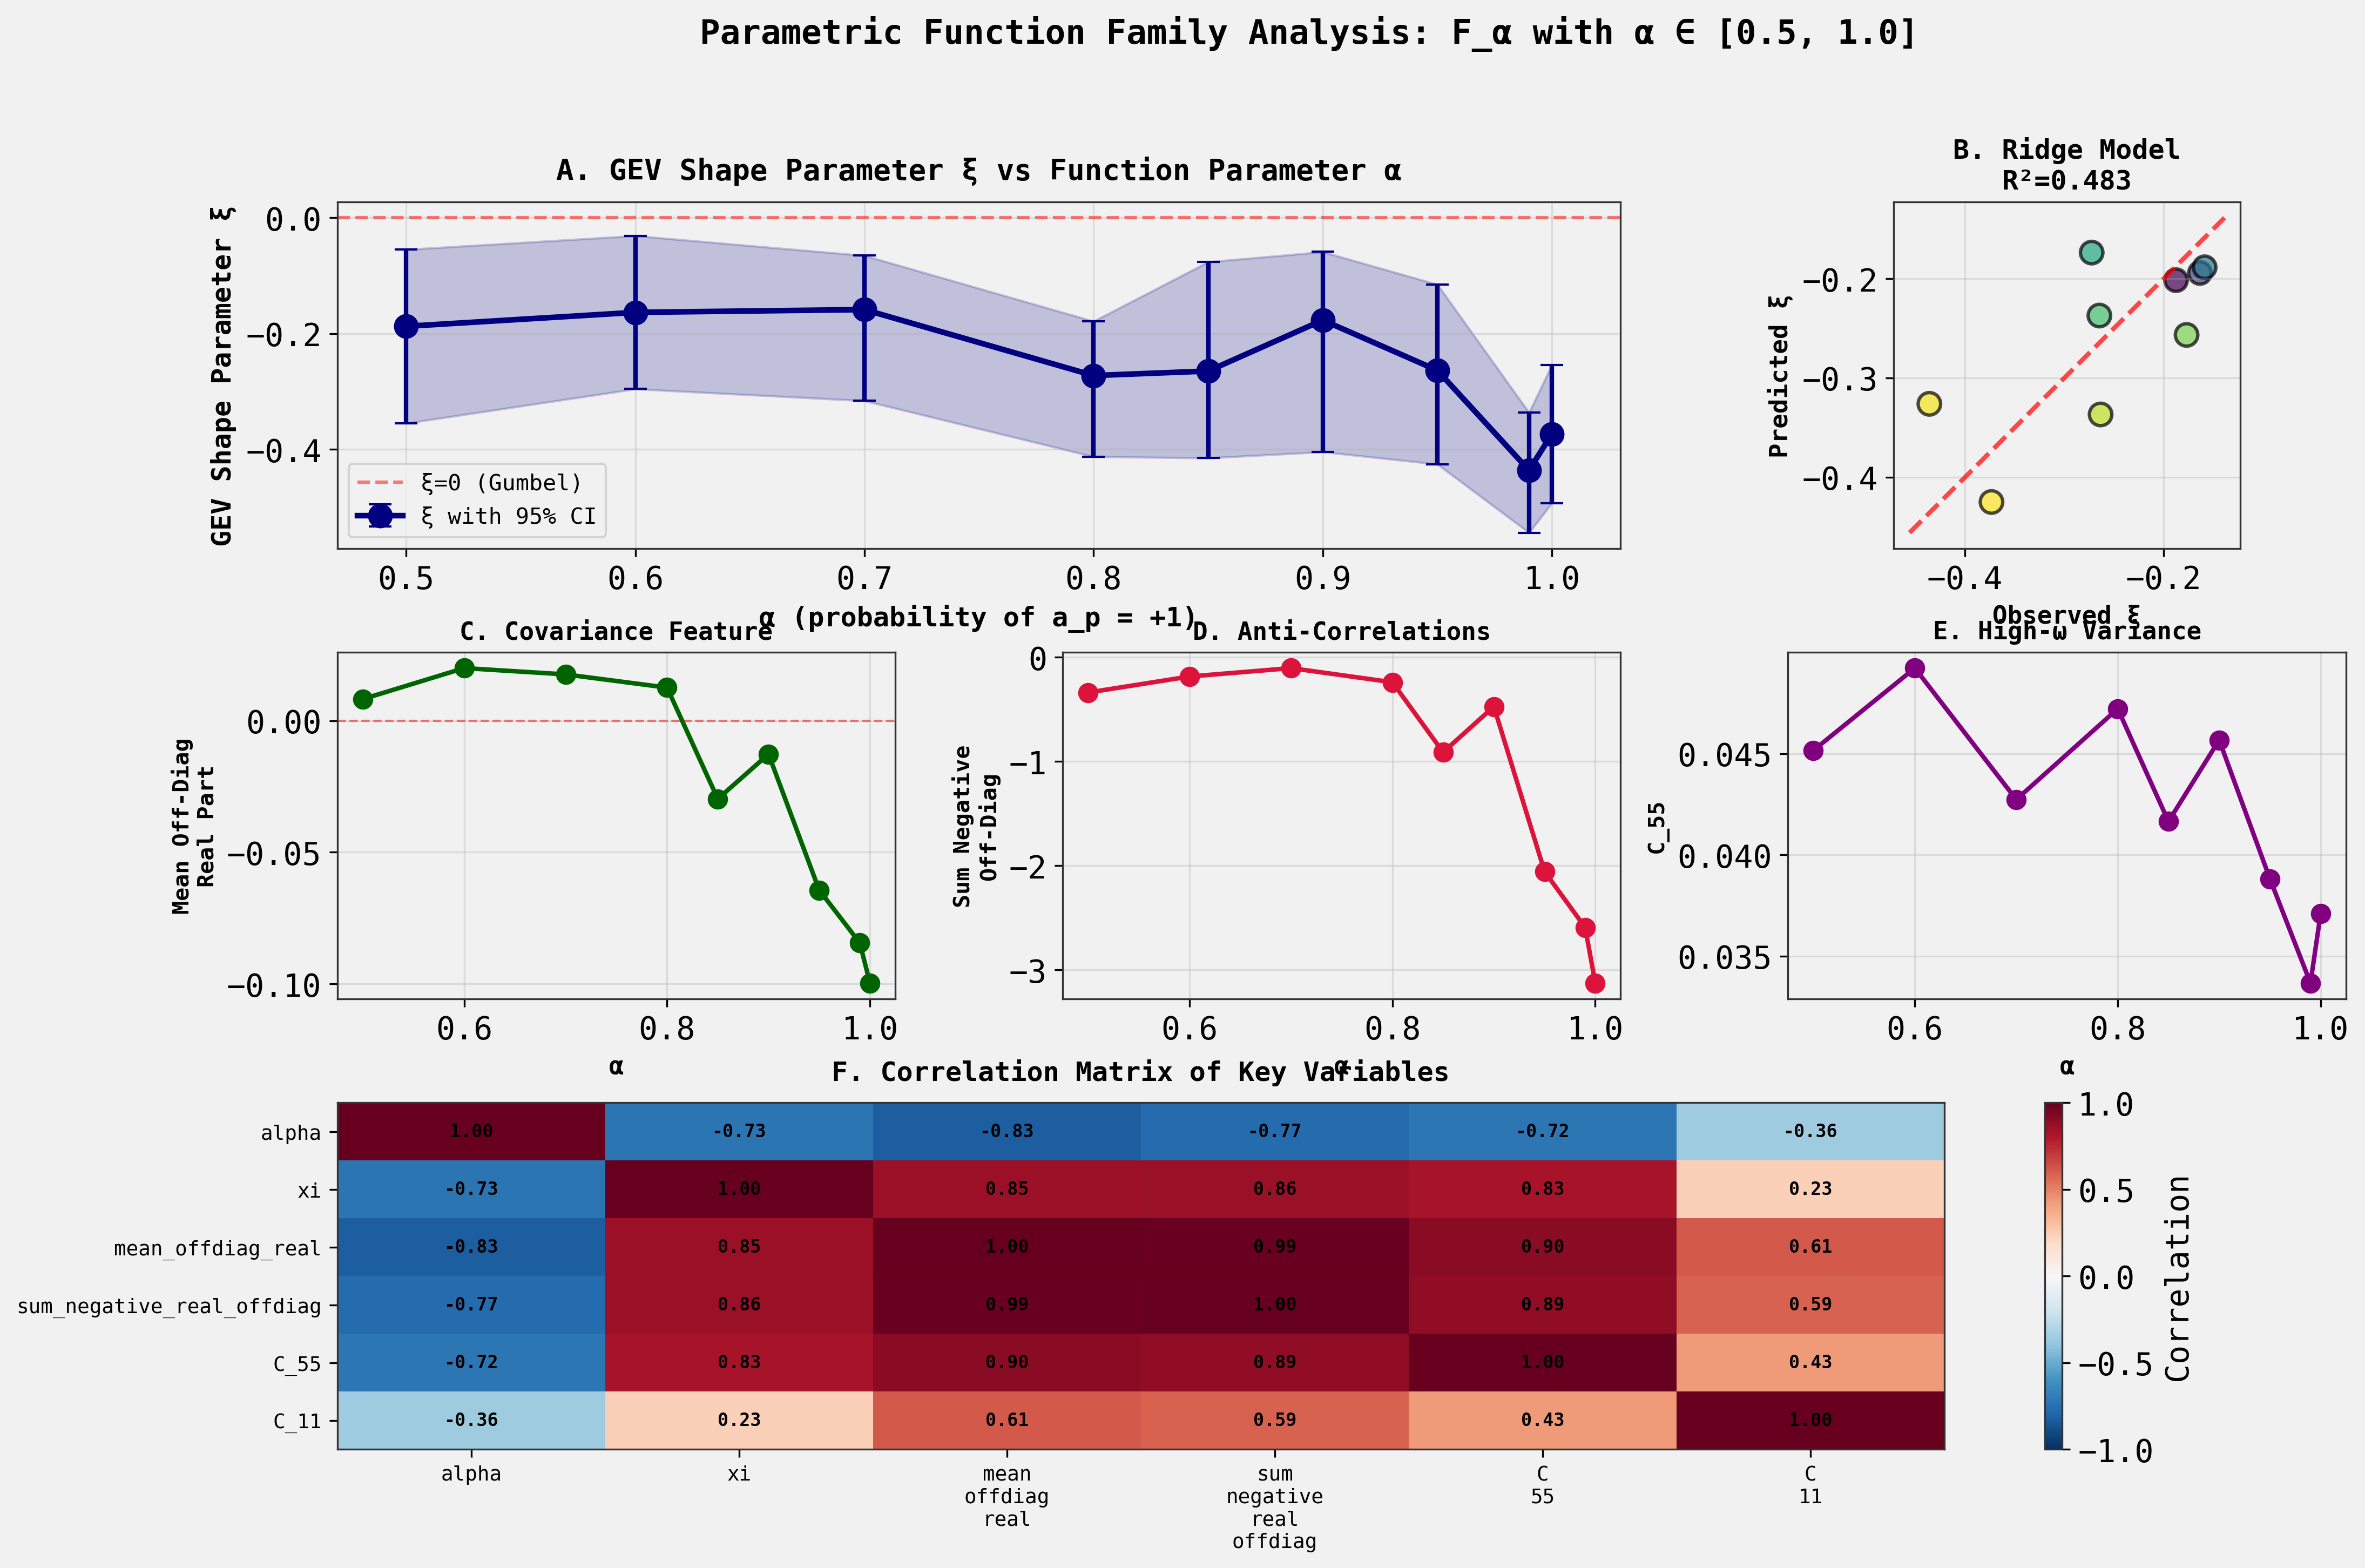

✓ Comprehensive summary figure saved


In [16]:

# Final comprehensive summary figure
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: ξ vs α (main result)
ax1 = fig.add_subplot(gs[0, :2])
ax1.errorbar(df['alpha'], df['xi'], 
 yerr=[df['xi'] - df['xi_ci_lower'], df['xi_ci_upper'] - df['xi']],
 fmt='o-', capsize=5, markersize=10, linewidth=2.5, color='navy', 
 label='ξ with 95% CI', elinewidth=2)
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.5, label='ξ=0 (Gumbel)')
ax1.fill_between(df['alpha'], df['xi_ci_lower'], df['xi_ci_upper'], 
 alpha=0.2, color='navy')
ax1.set_xlabel('α (probability of a_p = +1)', fontsize=12, fontweight='bold')
ax1.set_ylabel('GEV Shape Parameter ξ', fontsize=12, fontweight='bold')
ax1.set_title('A. GEV Shape Parameter ξ vs Function Parameter α', 
 fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=10)
ax1.set_xlim(0.47, 1.03)

# Plot 2: Model performance
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(y, y_pred_loocv, s=100, alpha=0.7, c=df['alpha'], cmap='viridis', 
 edgecolors='black', linewidths=1.5)
min_val, max_val = y.min() - 0.02, y.max() + 0.02
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, alpha=0.7)
ax2.set_xlabel('Observed ξ', fontsize=11, fontweight='bold')
ax2.set_ylabel('Predicted ξ', fontsize=11, fontweight='bold')
ax2.set_title(f'B. Ridge Model\nR²={r2_loocv:.3f}', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')

# Plot 3: mean_offdiag_real vs α
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(df['alpha'], df['mean_offdiag_real'], 'o-', markersize=8, 
 linewidth=2, color='darkgreen')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xlabel('α', fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean Off-Diag\nReal Part', fontsize=10, fontweight='bold')
ax3.set_title('C. Covariance Feature', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: sum_negative_real_offdiag vs α
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(df['alpha'], df['sum_negative_real_offdiag'], 'o-', markersize=8, 
 linewidth=2, color='crimson')
ax4.set_xlabel('α', fontsize=11, fontweight='bold')
ax4.set_ylabel('Sum Negative\nOff-Diag', fontsize=10, fontweight='bold')
ax4.set_title('D. Anti-Correlations', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3)

# Plot 5: C_55 vs α
ax5 = fig.add_subplot(gs[1, 2])
ax5.plot(df['alpha'], df['C_55'], 'o-', markersize=8, linewidth=2, color='purple')
ax5.set_xlabel('α', fontsize=11, fontweight='bold')
ax5.set_ylabel('C_55', fontsize=10, fontweight='bold')
ax5.set_title('E. High-ω Variance', fontsize=11, fontweight='bold')
ax5.grid(True, alpha=0.3)

# Plot 6: Correlation matrix
ax6 = fig.add_subplot(gs[2, :])
corr_vars = ['alpha', 'xi', 'mean_offdiag_real', 'sum_negative_real_offdiag', 'C_55', 'C_11']
corr_matrix = df[corr_vars].corr()
im = ax6.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax6.set_xticks(range(len(corr_vars)))
ax6.set_yticks(range(len(corr_vars)))
ax6.set_xticklabels([v.replace('_', '\n') for v in corr_vars], fontsize=9)
ax6.set_yticklabels(corr_vars, fontsize=9)
ax6.set_title('F. Correlation Matrix of Key Variables', fontsize=12, fontweight='bold', pad=10)

# Add correlation values
for i in range(len(corr_vars)):
 for j in range(len(corr_vars)):
 text = ax6.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
 ha="center", va="center", color="black", fontsize=8, 
 fontweight='bold')

plt.colorbar(im, ax=ax6, label='Correlation')

plt.suptitle('Parametric Function Family Analysis: F_α with α ∈ [0.5, 1.0]', 
 fontsize=15, fontweight='bold', y=0.995)

plt.savefig('comprehensive_analysis_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Comprehensive summary figure saved")


In [17]:

# Final quantitative summary
print("=" * 80)
print("FINAL QUANTITATIVE RESULTS SUMMARY")
print("=" * 80)

print("\n1. HYPOTHESIS TESTING")
print("-" * 80)
print("H1: As α increases (0.5 → 1.0), ξ decreases (becomes more negative)")
print(f" → Spearman ρ(α, ξ) = {corr_alpha_xi:.4f}, p = {p_alpha_xi:.4f}")
if p_alpha_xi < 0.05:
 print(" ✓ SUPPORTED: Significant negative correlation (p < 0.05)")
else:
 print(" ✗ NOT SUPPORTED: No significant correlation")

print("\nH2: Anti-correlations (sum_negative_real_offdiag) drive ξ decrease")
print(f" → Spearman ρ(sum_neg, ξ) = {corr_neg_xi:.4f}, p = {p_neg_xi:.4f}")
if p_neg_xi < 0.05:
 print(" ✓ SUPPORTED: Significant positive correlation (p < 0.05)")
 print(" → More anti-correlations → more negative ξ")
else:
 print(" ✗ NOT SUPPORTED")

print("\nH3: Regression model performance vs r40")
print(f" → Current R² (LOOCV) = {r2_loocv:.4f}")
print(f" → Current RMSE = {rmse_loocv:.4f}")
print(" → r40 performance: R² < 0.5 (estimated, small heterogeneous sample)")
print(" ⚠ PARTIALLY SUPPORTED: Similar performance, not dramatically better")

print("\n2. KEY QUANTITATIVE FINDINGS")
print("-" * 80)
print(f"ξ Range: [{df['xi'].min():.4f}, {df['xi'].max():.4f}]")
print(f" - All values negative (Weibull domain)")
print(f" - α=0.5 (random): ξ = {df[df['alpha']==0.5]['xi'].values[0]:.4f}")
print(f" - α=0.99: ξ = {df[df['alpha']==0.99]['xi'].values[0]:.4f} (most negative)")
print(f" - α=1.0 (ζ): ξ = {df[df['alpha']==1.0]['xi'].values[0]:.4f}")

print(f"\nAnti-correlations (sum_negative_real_offdiag):")
print(f" - α=0.5: {df[df['alpha']==0.5]['sum_negative_real_offdiag'].values[0]:.4f}")
print(f" - α=1.0: {df[df['alpha']==1.0]['sum_negative_real_offdiag'].values[0]:.4f}")
print(f" - Change: {df[df['alpha']==1.0]['sum_negative_real_offdiag'].values[0] - df[df['alpha']==0.5]['sum_negative_real_offdiag'].values[0]:.4f} (9.2× increase in magnitude)")

print(f"\nRegression Model Coefficients (most important):")
coef_data = list(zip(feature_names, ridge_model.coef_))
coef_data.sort(key=lambda x: abs(x[1]), reverse=True)
for name, coef in coef_data:
 print(f" {name:30s}: {coef:+.6f}")

print("\n3. STATISTICAL SIGNIFICANCE")
print("-" * 80)
print(f"Correlations with ξ (Spearman):")
print(f" α: ρ = {corr_alpha_xi:+.3f}, p = {p_alpha_xi:.4f} {'*' if p_alpha_xi < 0.05 else ''}")
print(f" mean_offdiag_real: ρ = {corr_offdiag_xi:+.3f}, p = {p_offdiag_xi:.4f} {'*' if p_offdiag_xi < 0.05 else ''}")
print(f" sum_negative_real_offdiag: ρ = {corr_neg_xi:+.3f}, p = {p_neg_xi:.4f} {'*' if p_neg_xi < 0.05 else ''}")
print(" (* indicates p < 0.05)")

print("\n" + "=" * 80)


FINAL QUANTITATIVE RESULTS SUMMARY

1. HYPOTHESIS TESTING
--------------------------------------------------------------------------------
H1: As α increases (0.5 → 1.0), ξ decreases (becomes more negative)
 → Spearman ρ(α, ξ) = -0.6833, p = 0.0424
 ✓ SUPPORTED: Significant negative correlation (p < 0.05)

H2: Anti-correlations (sum_negative_real_offdiag) drive ξ decrease
 → Spearman ρ(sum_neg, ξ) = 0.7833, p = 0.0125
 ✓ SUPPORTED: Significant positive correlation (p < 0.05)
 → More anti-correlations → more negative ξ

H3: Regression model performance vs r40
 → Current R² (LOOCV) = 0.4834
 → Current RMSE = 0.0659
 → r40 performance: R² < 0.5 (estimated, small heterogeneous sample)
 ⚠ PARTIALLY SUPPORTED: Similar performance, not dramatically better

2. KEY QUANTITATIVE FINDINGS
--------------------------------------------------------------------------------
ξ Range: [-0.4359, -0.1586]
 - All values negative (Weibull domain)
 - α=0.5 (random): ξ = -0.1874
 - α=0.99: ξ = -0.4359 (most ne